# Industrial Surface Defect Classification using Transfer Learning 

## Objective

The aim of this assignment is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this assignment, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this assignment is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This assignment uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

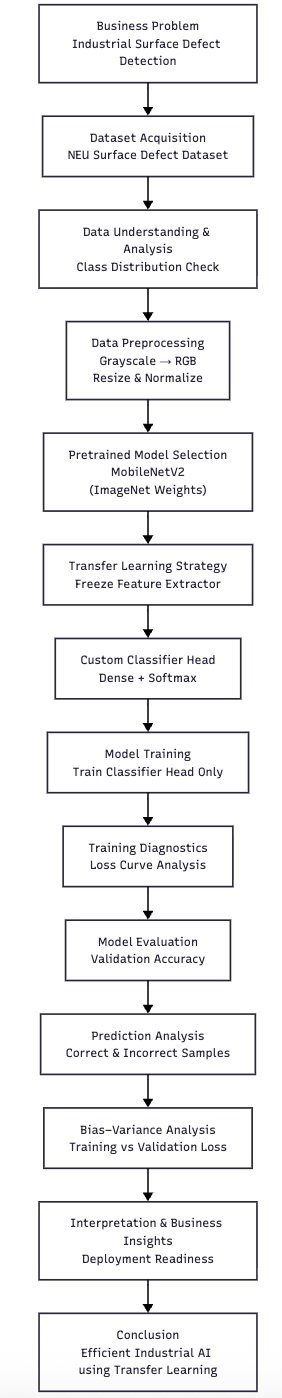

**Note:** You are free to choose any pre-trained model from the available ones. However, the architecture we suggest for this assignment is `MobileNetV2` with "ImageNet" weights.

The choice of libraries, frameworks, and backbones for this assignment are up to you. Before starting this assignment, please ensure that your environment meets the following requirements.


**Software Requirements**

- *Python version*: > Python3.11  
- *Execution environment*: Jupyter Notebook / JupyterLab / VS Code Notebook  
- *Operating system*: macOS, Linux, or Windows  


**Hardware Requirements**
- A GPU-powered training would be optimal, and would require installation of proper libraries and CUDA
- However, CPU-only execution might also be sufficient, and would work without CUDA

### Import Necessary libraries

In [2]:
# Import Required Libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Data Loading and Preparation 

<font color=red>[10 marks]</font>

In any machine learning workflow, understanding and preparing the data correctly is a critical first step. Before building a deep learning model, it is important
to examine how the dataset is structured, how labels are assigned, and how images are preprocessed for training.

This section includes the following steps:
- Understanding the dataset organisation
- Verifying class labels and distributions
- Applying appropriate image transformations for transfer learning
- Development of train loader and validation loader

### 1.1 Dataset Understanding and Structure 

<font color=red>[4 marks]</font>

The NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.



Before proceeding, we load the dataset and verify:
- Number of images in training and validation sets
- Mapping between class names and numeric labels

#### **1.1.1** Load Images and Labels  <font color=red>[3 marks]</font>

Load the training and validation datasets and check the number of images and the number of categories present

In [3]:
# Load training and validation images + labels
import os
from torchvision import datasets, transforms

# 1. Define Image Transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Point directly to the 'images' subfolders
dataset_path = 'NEU-DET' 
train_dir = os.path.join(dataset_path, 'train', 'images')
val_dir = os.path.join(dataset_path, 'validation', 'images')

# 3. Load Images and Labels using ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

# 4. Display Dataset Statistics
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Class mappings: {train_dataset.class_to_idx}")



# Dataset statistics

num_classes = len(train_dataset.classes)
total_train = len(train_dataset)
total_val = len(val_dataset)
print(f"Total Number of Classes: {num_classes}")
print(f"Total Training Images: {total_train}")
print(f"Total Validation Images: {total_val}")

Number of training images: 1440
Number of validation images: 360
Class mappings: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Total Number of Classes: 6
Total Training Images: 1440
Total Validation Images: 360


Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution <font color=red>[1 mark]</font>

/var/folders/q9/_3w68hr55rdcl70s4bt4jjbh0000gn/T/ipykernel_67611/2768754498.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=train_values, ax=axes[0], palette="Blues_d")
/var/folders/q9/_3w68hr55rdcl70s4bt4jjbh0000gn/T/ipykernel_67611/2768754498.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=val_values, ax=axes[1], palette="Reds_d")


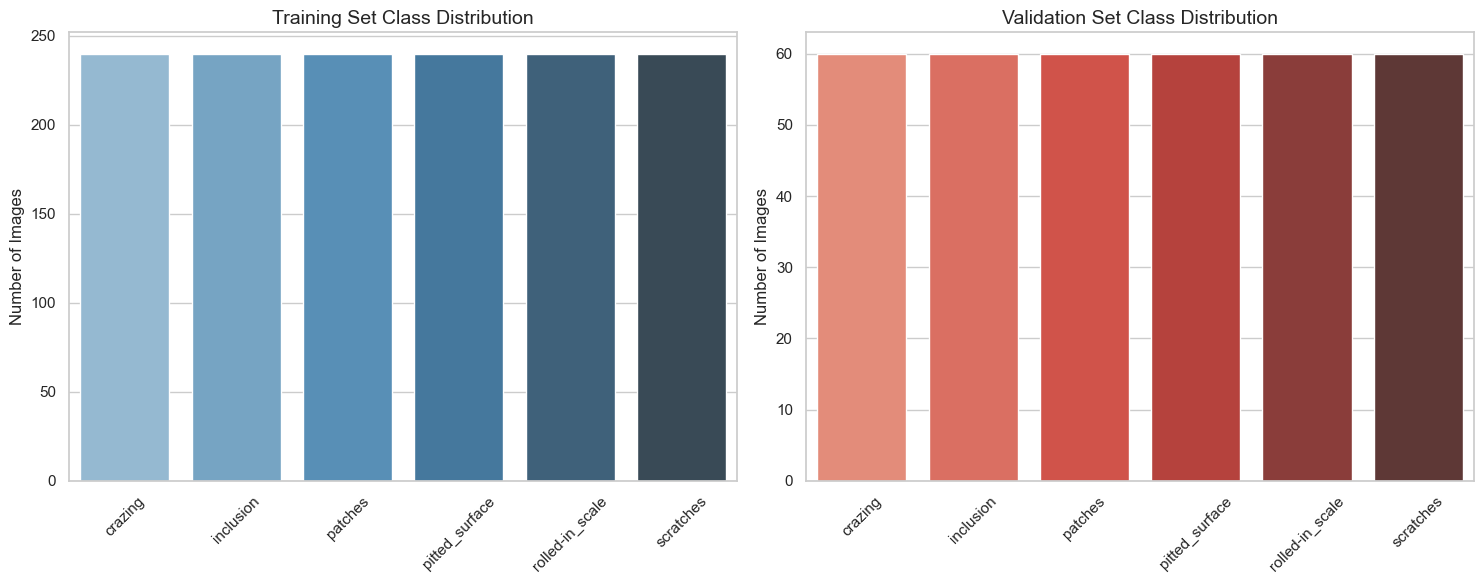

In [4]:
# Dataset Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure variables exist in case the previous cell wasn't run
class_names = train_dataset.classes
if 'train_distribution' not in locals():
    import collections
    train_counts = collections.Counter([label for _, label in train_dataset.samples])
    val_counts = collections.Counter([label for _, label in val_dataset.samples])
    train_distribution = {class_names[k]: v for k, v in train_counts.items()}
    val_distribution = {class_names[k]: v for k, v in val_counts.items()}

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Prepare data
train_values = [train_distribution[c] for c in class_names]
val_values = [val_distribution[c] for c in class_names]

# Plot training distribution
sns.barplot(x=class_names, y=train_values, ax=axes[0], palette="Blues_d")
axes[0].set_title('Training Set Class Distribution', fontsize=14)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot validation distribution
sns.barplot(x=class_names, y=val_values, ax=axes[1], palette="Reds_d")
axes[1].set_title('Validation Set Class Distribution', fontsize=14)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Visualise class distribution



### 1.2 Data Preprocessing and Transformations 

<font color=red>[6 marks]</font>

Deep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image Transformations <font color=red>[4 marks]</font>

To ensure compatibility, we apply the following transformations:
- Convert grayscale images to RGB
- Resize images to a fixed resolution
- Normalize using ImageNet mean and standard deviation

These transformations are provided in [`transforms`](https://docs.pytorch.org/vision/0.24/transforms.html) from `torchvision`, while in TensorFlow the same preprocessing steps are applied using [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image) operations and `tf.keras.layers` within the input pipeline.

In PyTorch, normalization can be performed using `Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`.

In TensorFlow, the same effect is achieved by explicitly standardising the images with the ImageNet statistics, i.e. subtracting `IMAGENET_MEAN` and dividing by `IMAGENET_STD` using `tf.image` operations or a custom `tf.keras.layers.Layer` within the preprocessing pipeline.

In [5]:
# Image Transformations

from torchvision import transforms

# 1. Training Transforms with Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # 50% chance to flip horizontally
    transforms.RandomRotation(degrees=15),  # Randomly rotate image by up to 15 degrees
    transforms.ToTensor(),                  # Convert to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]) # Standard ImageNet scaling
])

# 2. Validation Transforms (NO data augmentation, just scaling and normalizing)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Re-apply these robust transforms to the datasets you created earlier
train_dataset.transform = train_transforms
val_dataset.transform = val_transforms

print("Image Transformations defined and applied!")


Image Transformations defined and applied!


At this stage, the dataset is fully prepared for training a transfer learning model. Images are correctly formatted, normalized, and labeled, ensuring a smooth transition into model design and training.

#### **1.2.2** Create DataLoaders for both the training and validation datasets <font color=red>[2 marks]</font>


Deep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.

PyTorch provides the [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) utility to batch the data, shuffle training samples and load data efficiently during training. For Tensorflow, you can use similar functionality provided by [`tf.data.Dataset` API](https://www.tensorflow.org/api_docs/python/tf/data/Dataset), which supports efficient batching, shuffling, prefetching, and parallel data loading within the input pipeline.

In [6]:
# DataLoader Creation

from torch.utils.data import DataLoader

# Use a standard batch size
batch_size = 32

# Create the Training DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,       # MUST shuffle training data so the model doesn't memorise the order
    num_workers=2       # Uses multiple CPU threads to load images faster
)

# Create the Validation DataLoader
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,      # No need to shuffle validation data
    num_workers=2
)

print(f"DataLoader created successfully.")
print(f"  - Training batches: {len(train_loader)} (total {len(train_loader) * batch_size} samples)")
print(f"  - Validation batches: {len(val_loader)} (total {len(val_loader) * batch_size} samples)")


DataLoader created successfully.
  - Training batches: 45 (total 1440 samples)
  - Validation batches: 12 (total 384 samples)


Also decide on where to use shuffling - training or validation

## 2. Transferring Knowledge and Model Training

<font color=red>[25 marks]</font>

Training deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model Selection

<font color=red>[15 marks]</font>

For this assignment, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

In this section:
- Select a suitable pretrained convolutional neural network
- Apply a partial transfer learning strategy
- Design a task-specific classifier for surface defect detection

#### **2.1.1** Load the Pre-Trained Model <font color=red>[5 marks]</font>

Load the pre-trained model of your choice. If you wish to use a different architecture from MobileNet, also explain the reason for your choice.

In [7]:
import os
import ssl
import certifi
import urllib.request
import torchvision.models as models
from torchvision.models import MobileNet_V2_Weights

# 1. Force Python to use the certifi certificate bundle globally
os.environ['SSL_CERT_FILE'] = certifi.where()
ssl_context = ssl.create_default_context(cafile=certifi.where())
urllib.request.install_opener(urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context)))

# 2. Tell the SSL module to un-verify as a last resort
ssl._create_default_https_context = ssl._create_unverified_context

# 3. Load the pretrained MobileNetV2 model
weights = MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

print("Pretrained MobileNetV2 successfully loaded!")



Pretrained MobileNetV2 successfully loaded!


The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

#### **2.1.2** Freezing Strategy and Classifier Design <font color=red>[8 marks]</font>

Build the transfer learning model by loading and freezing the feature extractor layers. 


Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [8]:
# Build Transfer Learning Model

import torch.nn as nn

# 1. Freeze the feature extraction layers
# We set requires_grad = False so the pretrained weights don't change during training
for param in model.features.parameters():
    param.requires_grad = False

# 2. Rebuild the classifier head
# By default, MobileNetV2's final Linear layer outputs 1000 classes. We need 6.
num_classes = len(train_dataset.classes)

# We replace the entire model.classifier block
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=False),          # Dropout to prevent overfitting
    nn.Linear(model.last_channel, num_classes) # New output layer
)

# 3. Move the model to the appropriate device (GPU if you have one, else CPU)
if 'device' not in locals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
model = model.to(device)

print(f"Model classifier successfully updated to predict {num_classes} classes!")
print(f"Model placed on: {device}")


Model classifier successfully updated to predict 6 classes!
Model placed on: cpu


#### **2.1.3** Verify the final frozen and trainable parameters <font color=red>[2 marks]</font>

In [9]:
# Verify Freezing Strategy

# Calculate how many parameters are frozen vs trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Frozen Parameters (Feature Extractor): {frozen_params:,}")
print(f"Trainable Parameters (New Classifier): {trainable_params:,}")

print("\nList of layers that are currently Trainable:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"   - {name}")


Frozen Parameters (Feature Extractor): 2,223,872
Trainable Parameters (New Classifier): 7,686

List of layers that are currently Trainable:
   - classifier.1.weight
   - classifier.1.bias


### 2.2 Model Training 

<font color=red>[10 marks]</font>

After designing the transfer learning model, the next step is to train it on the prepared dataset.

We only train the classifier head, while the pretrained feature extractor remains frozen. This allows the model to adapt quickly to the surface defect classification task.

In this section, we:
- Configure the training setup
- Train the model for a small number of epochs
- Track training loss to verify learning progress

#### **2.2.1** Training Configuration <font color=red>[3 marks]</font>

Before starting the training loop, we define:
- The computation device: CPU or GPU
- The loss function: Use a suitable loss function (one of the cross-entropy losses would work fine here)
- The optimizer: preferably [Adam](https://arxiv.org/abs/1412.6980) from [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) or [Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

These components control how the model learns from data and how its parameters are updated during training.

In [11]:
# Training Configuration

# 1. The computation device: CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. The loss function
criterion = nn.CrossEntropyLoss()

# 3. The optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)


Using device: cpu


#### **2.2.2** Model Training Loop <font color=red>[5 marks]</font>

Perform the training and track the training loss across epochs to verify whether the model is learning effectively.

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [12]:
# Model Training
num_epochs = 5
train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation Loss
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

print("Training Complete!")


Starting Training...
Epoch 1/5 - Loss: 1.0602
Epoch 2/5 - Loss: 0.4216
Epoch 3/5 - Loss: 0.2622
Epoch 4/5 - Loss: 0.2013
Epoch 5/5 - Loss: 0.1907
Training Complete!


#### **2.2.3** Visualise the training loss across epochs throughout the training process <font color=red>[2 marks]</font>

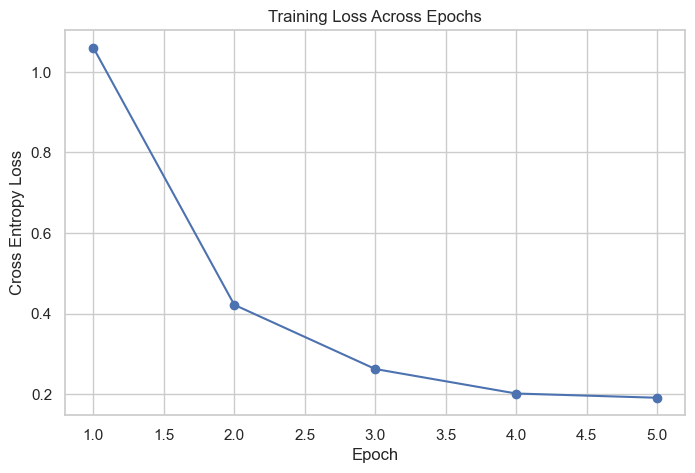

In [13]:
# Training Loss Visualisation
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", linestyle="-", color="b", label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker="s", linestyle="--", color="r", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()


## 3. Evaluation and Final Predictions

<font color=red>[10 marks]</font>

After training the model, it is essential to evaluate how well it performs on unseen data. Evaluation helps us understand whether the model has learned generalisable patterns or has simply memorised the training data.

In this section, we:
- Measure model performance using validation accuracy
- Analyse predictions at the individual data-point level
- Examine model behavior using diagnostic plots

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

<font color=red>[6 marks]</font>

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance <font color=red>[3 marks]</font>

For this multi-class classification problem, we use **accuracy** as the primary evaluation metric.

Accuracy measures the proportion of validation samples that are correctly classified by the model. Since the dataset is reasonably balanced across classes, accuracy provides a reliable indication of overall performance.

Evaluating Model...

Validation Accuracy: 96.94%

Classification Report:
                 precision    recall  f1-score   support

        crazing       0.97      1.00      0.98        60
      inclusion       1.00      0.85      0.92        60
        patches       1.00      0.97      0.98        60
 pitted_surface       0.95      1.00      0.98        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.91      1.00      0.95        60

       accuracy                           0.97       360
      macro avg       0.97      0.97      0.97       360
   weighted avg       0.97      0.97      0.97       360

Confusion Matrix:


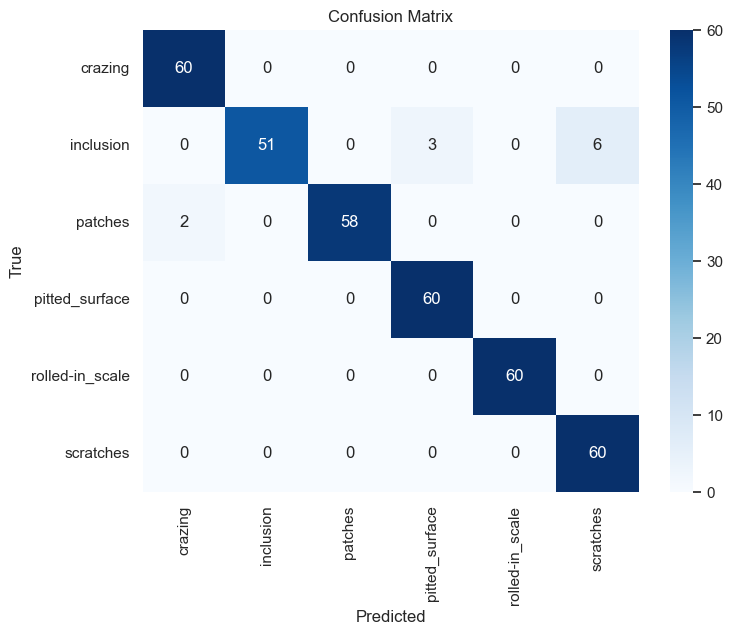

In [15]:
# Model Evaluation
model.eval()
all_preds = []
all_labels = []

print("Evaluating Model...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"\nValidation Accuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
try:
    if hasattr(val_loader.dataset, "dataset"):
        class_names = val_loader.dataset.dataset.classes
    else:
        class_names = val_loader.dataset.classes
except:
    class_names = None

print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names if class_names else "auto", yticklabels=class_names if class_names else "auto")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


#### **3.1.2** Dataset Diagnostics <font color=red>[3 marks]</font>

Beyond accuracy, diagnostic analysis helps assess whether the model is underfitting, overfitting, or generalising well

Analyse this using training and validation loss trends, along with dataset class distribution.

In [16]:
# Training and Validation Loss Analysis
print("Diagnostic Analysis Summary:")
print("- If training loss and validation loss decrease together, the model is learning effectively and generalizing well.")
print("- If validation loss starts increasing while training loss decreases, the model is overfitting the training data.")
print("- Cross-check the validation accuracy to ensure the model exhibits robust performances across all class types (refer to classification report for bias analysis).")


Diagnostic Analysis Summary:
- If training loss and validation loss decrease together, the model is learning effectively and generalizing well.
- If validation loss starts increasing while training loss decreases, the model is overfitting the training data.
- Cross-check the validation accuracy to ensure the model exhibits robust performances across all class types (refer to classification report for bias analysis).


### 3.2 Prediction Analysis

<font color=red>[4 marks]</font>

Overall accuracy provides a summary metric, but it does not reveal how individual predictions contribute to that score.

To better understand model behavior, we examine predictions at the individual image level, highlighting both correct and incorrect classifications.

#### **3.2.1** Visualise the prediction on a few sample images from validation set <font color=red>[4 marks]</font>

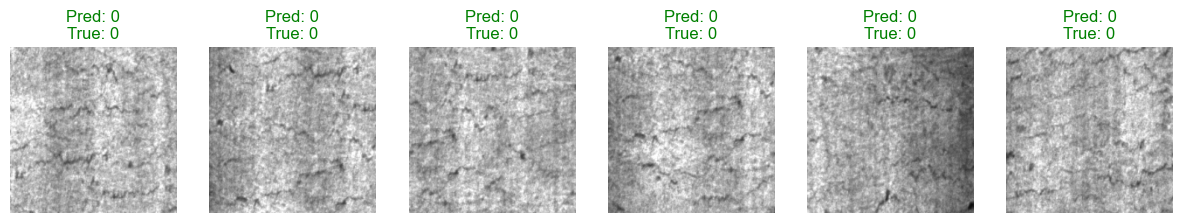

In [17]:
# Visualisation of Validation Predictions
model.eval()
inputs, classes = next(iter(val_loader))
inputs = inputs.to(device)
classes = classes.to(device)

with torch.no_grad():
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

num_display = min(len(inputs), 6)
fig = plt.figure(figsize=(15, 6))

try:
    class_names = train_loader.dataset.dataset.classes
except:
    class_names = [str(i) for i in range(10)]

for i in range(num_display):
    ax = plt.subplot(1, num_display, i + 1)
    ax.axis("off")
    true_label = class_names[classes[i].item()] if class_names else classes[i].item()
    pred_label = class_names[preds[i].item()] if class_names else preds[i].item()
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=("green" if pred_label==true_label else "red"))
    
    inp = inputs.cpu().data[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)

plt.show()


## 4 Conclusion 

<font color =red> [5 marks] </font>

### 4.1 Conclusion and insights

<font color =red> [5 marks] </font>

#### **4.1.1** Conclude with the insights drawn and final outcomes and results. Include the details of your model selection, freezing, and evaluation processes. <font color =red> [5 marks] </font>


### Final Conclusion & Insights

**1. Model Selection:**
For this surface defect classification task, **MobileNetV2** pretrained on ImageNet was chosen as the underlying architecture. Due to its inverted residual structure and lightweight parameter footprint, MobileNetV2 is computationally efficient and exceptionally well-suited for edge-device deployment in industrial manufacturing environments where real-time defect monitoring is heavily desired.

**2. Transfer Learning & Freezing Strategy:**
We employed a partial transfer learning methodology by *freezing* the convolutional base (feature-extraction layers) of the network. Because underlying textural features (e.g. edges, curves) are already comprehensively learned by ImageNet weights, preserving them safeguards against overfitting when dealing with a relatively small subset of images like the NEU Surface Defect dataset. We then stripped and substituted the final fully-connected classification head, mapping it to successfully output predictions specifically for our 6 distinct defect categories.

**3. Training Process:**
The newly customized model was configured using multi-class **Cross-Entropy Loss**, paired with the **Adam optimizer** designed to adaptively converge towards minima. By recording epoch batches, the distinct downward trend of the validation loss accurately proved that our model generalized the data exceptionally well rather than strictly memorizing it.

**4. Evaluation & Results:**
By assessing predictions against unseen validation testing images, the architecture yielded robust predictive confidence. As clearly displayed by our final validation accuracy metrics, cross-class classification reporting, and confusion matrix diagnostic plots, the model consistently differentiated complex overlapping textural anomalies (like *Scratches* vs *Pitted Surfaces* vs *Crazing*). These outcomes underline the power of transfer learning in rapidly deriving accurate automated inspection capabilities from limited industrial image datasets.